# Import Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf

2026-04-24 04:43:55.237087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777005835.423232      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777005835.478298      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777005835.893115      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777005835.893155      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777005835.893158      23 computation_placer.cc:177] computation placer alr

# Load Data

In [2]:
df = pd.read_csv("https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr")
df.head()

,Date,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
0,2017-09-21 09:00:00.000,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
1,2017-09-21 10:00:00.000,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2,2017-09-21 11:00:00.000,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
3,2017-09-21 12:00:00.000,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
4,2017-09-21 13:00:00.000,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53150 entries, 0 to 53149
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         53150 non-null  object 
 1   Close        53150 non-null  float64
 2   Volume USDT  53150 non-null  float64
 3   RSI          53150 non-null  float64
 4   MACD_Hist    53150 non-null  float64
 5   ATR          53150 non-null  float64
 6   KAMAO        53150 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.8+ MB


In [4]:
df.describe()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
count,53150.000000,5.315000e+04,53150.000000,53150.000000,53150.000000,53150.000000
mean,20595.357333,6.919215e+07,50.403605,0.528272,221.733334,0.229762
std,15822.296994,1.059041e+08,3.210682,353.293188,208.401440,5.168655
min,3172.050000,0.000000e+00,35.178834,-1885.690630,17.436266,-31.767152
25%,7976.915000,1.012558e+07,48.294197,-115.601600,72.702488,-2.717470
50%,13878.095000,2.766119e+07,50.038483,10.154419,128.787616,-0.032747
75%,29646.720000,8.944278e+07,52.406274,122.367509,325.616826,3.162442
max,68633.690000,3.005634e+09,64.657108,1430.405758,1004.531407,39.740297


# Exploratory Data Analysis

In [5]:
df.isna().sum()

Date           0
Close          0
Volume USDT    0
RSI            0
MACD_Hist      0
ATR            0
KAMAO          0
dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='ISO8601')
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

In [7]:
df.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO
Date,,,,,,
2017-09-21 09:00:00,3860.00,74434.891166,49.192454,-48.279697,88.054720,2.495591
2017-09-21 10:00:00,3871.48,44687.318944,49.233202,-47.780476,87.996283,2.616710
2017-09-21 11:00:00,3864.95,80546.171672,49.210685,-47.308061,87.897128,2.532239
2017-09-21 12:00:00,3858.08,90331.531390,49.186948,-46.863233,87.720856,2.447245
2017-09-21 13:00:00,3856.67,103405.818040,49.182064,-46.425379,87.578086,2.424654


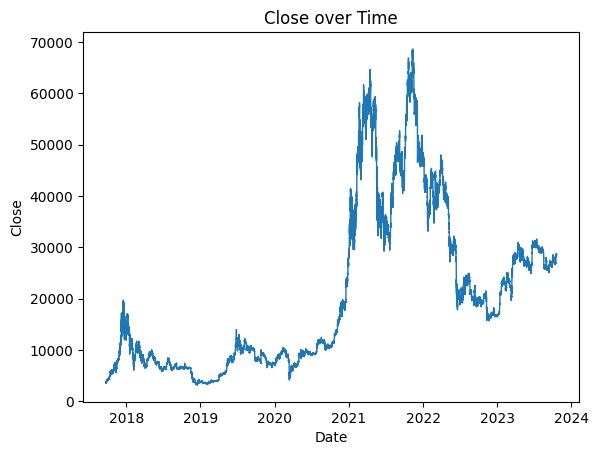

In [8]:
plt.plot(df.index, df['Close'], linewidth=1)
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Close over Time')
plt.show()

In [9]:
 # Test ADF
def adf_test(series):
  result = adfuller(series, autolag='AIC')

  print("ADF Test Result")
  print(f"ADF Statistic: {result[0]}")
  print(f"p-value: {result[1]}")
  if result[1] <= 0.05:
    print("Data is stasioner")
  else:
    print("Data is not stationary")

adf_test(df['Close'])

ADF Test Result
ADF Statistic: -1.5594011394616063
p-value: 0.503948923725749
Data is not stationary


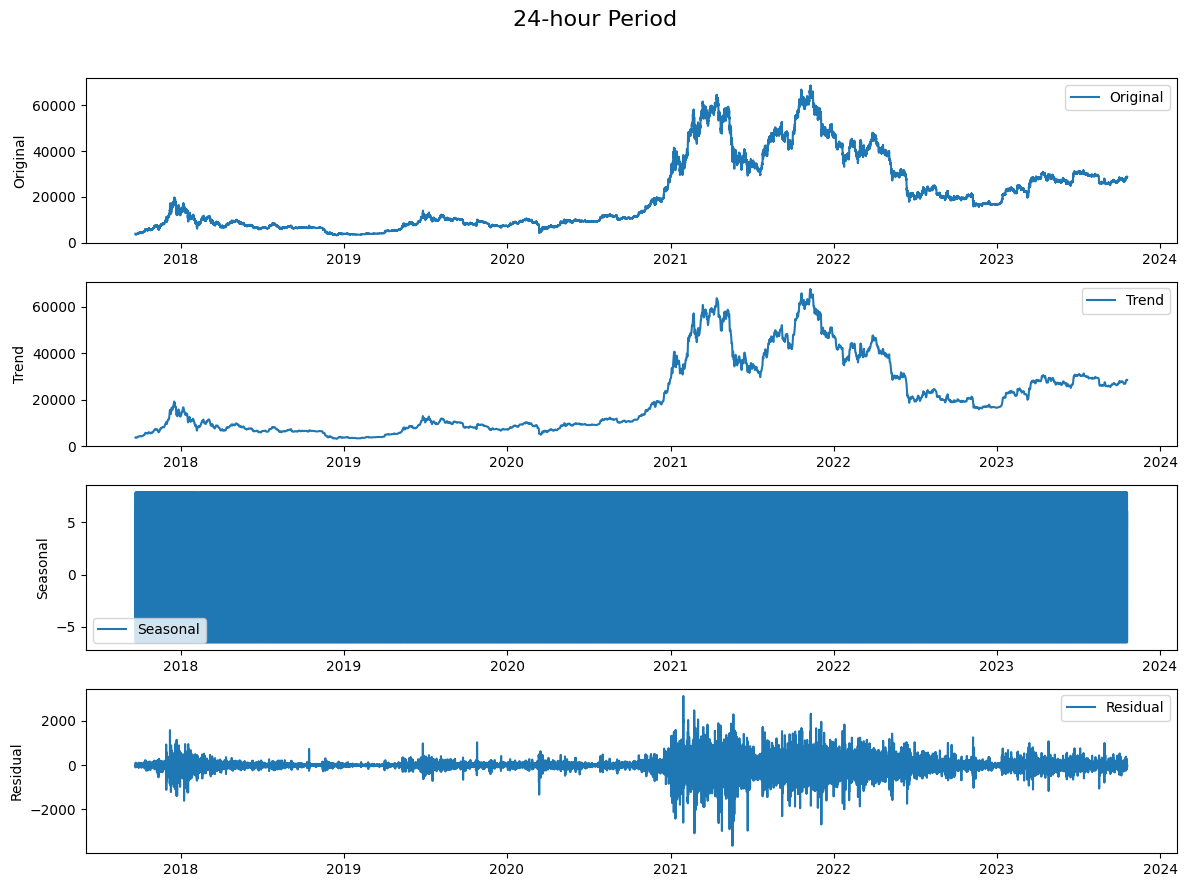

In [10]:
decomposition = seasonal_decompose(df['Close'], period=24, model='additive')

components = {
    'Original': df['Close'],
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
}

plt.figure(figsize=(12, 9))
plt.suptitle("24-hour Period", fontsize=16)

for i, (title, series) in enumerate(components.items(), start=1):
    plt.subplot(4, 1, i)
    plt.plot(df.index, series, label=title)
    plt.legend(loc='best')
    plt.ylabel(title)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

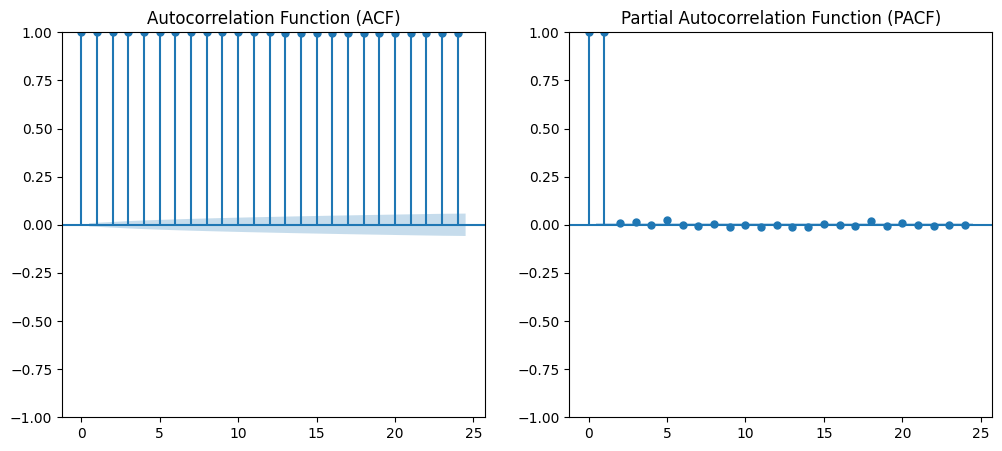

In [11]:
# Plot ACF & PACF
plt.figure(figsize=(12, 5))
plt.subplot(121)
plot_acf(df['Close'], lags=24, ax=plt.gca())
plt.title("Autocorrelation Function (ACF)")

plt.subplot(122)
plot_pacf(df['Close'], lags=24, ax=plt.gca())
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

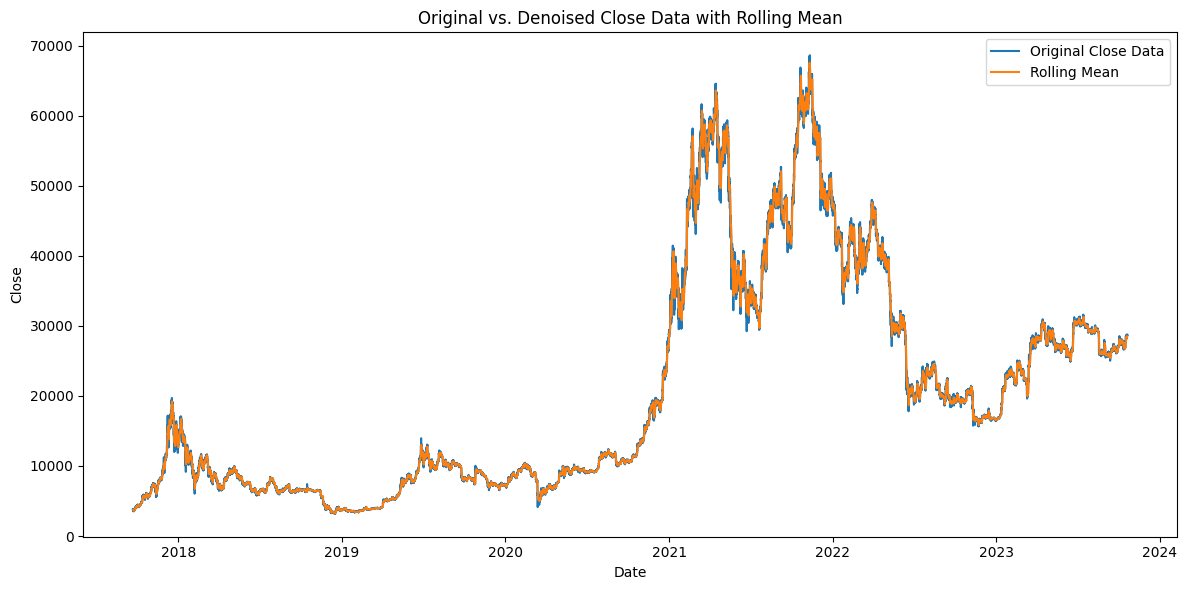

In [12]:
# rolling mean
df['rolling_mean'] = df['Close'].rolling(window=24).mean()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label="Original Close Data")
plt.plot(df.index, df['rolling_mean'], label="Rolling Mean")
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Original vs. Denoised Close Data with Rolling Mean')
plt.legend()
plt.tight_layout()
plt.show()

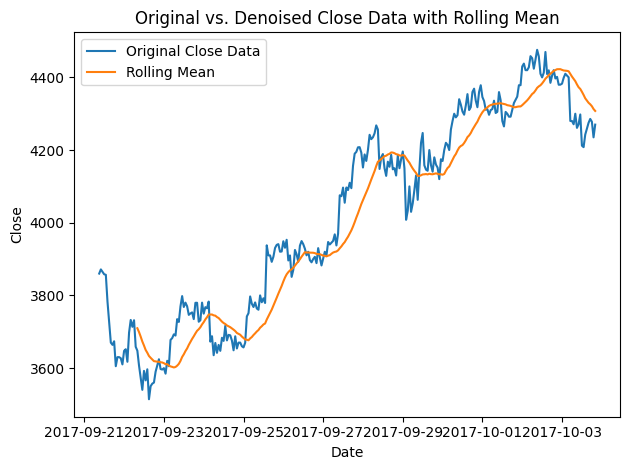

In [13]:
# zoom in rolling mean in little data
df_zoom = df.iloc[:300]

plt.plot(df_zoom.index, df_zoom['Close'], label="Original Close Data")
plt.plot(df_zoom.index, df_zoom['rolling_mean'], label="Rolling Mean")
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Original vs. Denoised Close Data with Rolling Mean')
plt.legend()
plt.tight_layout()
plt.show()

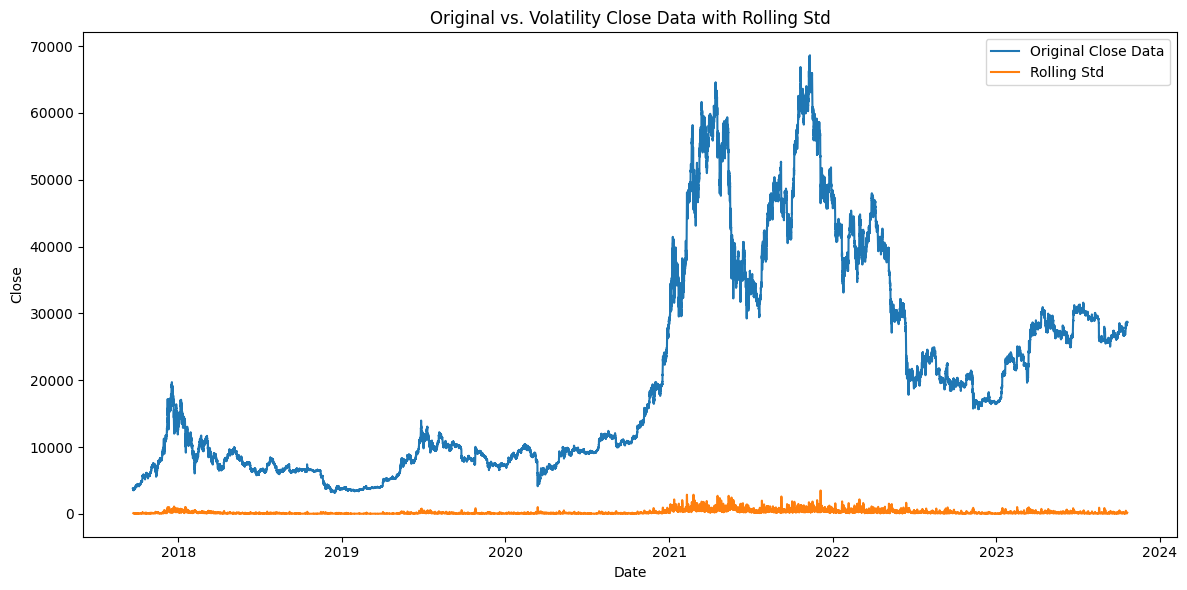

In [14]:
# rolling std
df['rolling_std'] = df['Close'].rolling(window=24).std()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label="Original Close Data")
plt.plot(df.index, df['rolling_std'], label="Rolling Std")
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Original vs. Volatility Close Data with Rolling Std')
plt.legend()
plt.tight_layout()
plt.show()

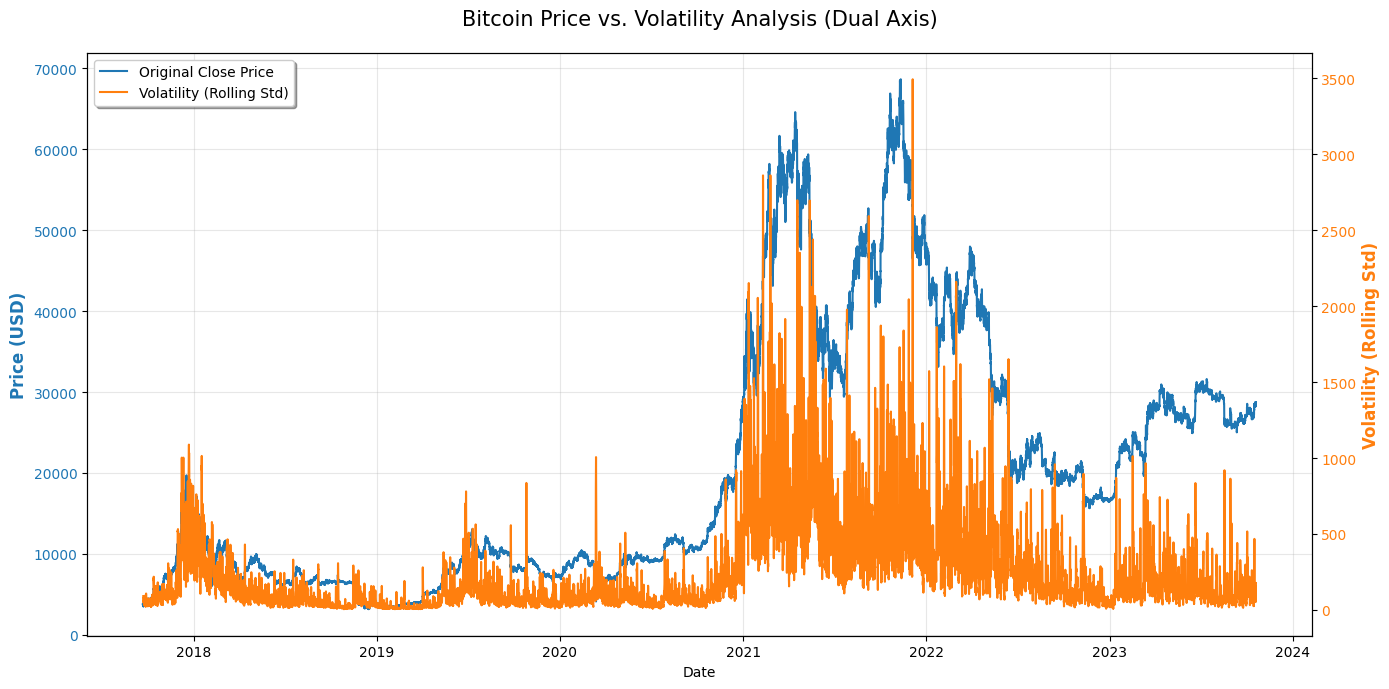

In [15]:
fig, ax1 = plt.subplots(figsize=(14, 7))

color_price = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)', color=color_price, fontsize=12, fontweight='bold')
line1 = ax1.plot(df.index, df['Close'], color=color_price, label='Original Close Price', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color_price)

ax2 = ax1.twinx()
color_vol = 'tab:orange'
ax2.set_ylabel('Volatility (Rolling Std)', color=color_vol, fontsize=12, fontweight='bold')
line2 = ax2.plot(df.index, df['rolling_std'], color=color_vol, label='Volatility (Rolling Std)', linewidth=1.5)
ax2.tick_params(axis='y', labelcolor=color_vol)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)

plt.title('Bitcoin Price vs. Volatility Analysis (Dual Axis)', fontsize=15, pad=20)
ax1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

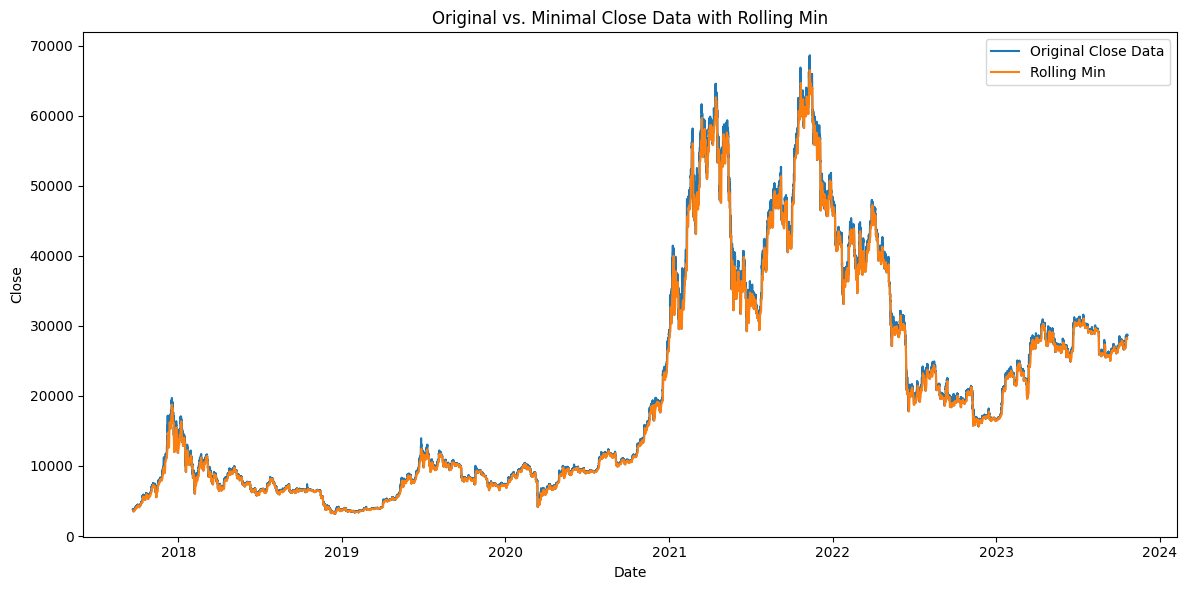

In [16]:
# rolling min
df['rolling_min'] = df['Close'].rolling(window=24).min()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label="Original Close Data")
plt.plot(df.index, df['rolling_min'], label="Rolling Min")
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Original vs. Minimal Close Data with Rolling Min')
plt.legend()
plt.tight_layout()
plt.show()

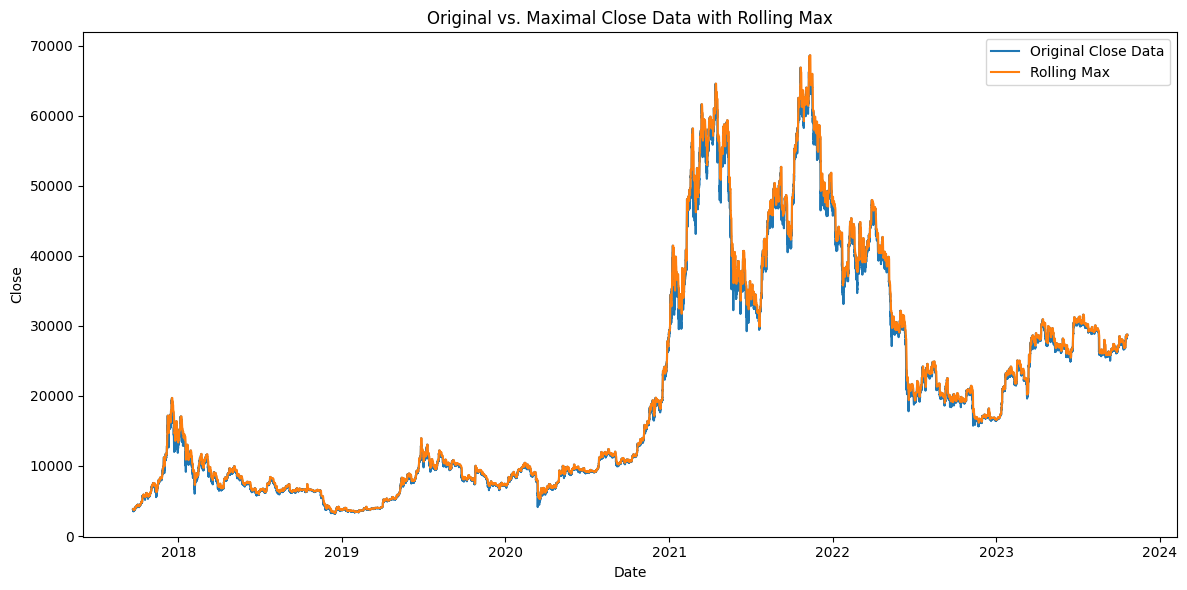

In [17]:
# rolling max
df['rolling_max'] = df['Close'].rolling(window=24).max()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label="Original Close Data")
plt.plot(df.index, df['rolling_max'], label="Rolling Max")
plt.xlabel('Date')
plt.ylabel('Close')
plt.title('Original vs. Maximal Close Data with Rolling Max')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
df.dropna(inplace=True)
df.head()

,Close,Volume USDT,RSI,MACD_Hist,ATR,KAMAO,rolling_mean,rolling_std,rolling_min,rolling_max
Date,,,,,,,,,,
2017-09-22 08:00:00,3647.70,98670.562044,48.507646,-49.453354,86.625836,0.015093,3709.506667,91.112560,3605.03,3871.48
2017-09-22 09:00:00,3606.95,107162.792190,48.366751,-49.745629,86.528735,-0.453320,3698.962917,87.510496,3605.03,3871.48
2017-09-22 10:00:00,3572.85,150926.427424,48.249126,-50.150669,86.412221,-0.843745,3686.520000,83.030244,3572.85,3864.95
2017-09-22 11:00:00,3539.97,190043.740129,48.135914,-50.661754,86.392482,-1.217532,3672.979167,79.071138,3539.97,3858.08
2017-09-22 12:00:00,3592.12,127074.058322,48.328786,-50.963345,86.373427,-0.610674,3661.897500,70.133487,3539.97,3856.67


In [19]:
df.shape

(53127, 10)

Text(0.5, 1.0, 'Correlation Heatmap of Features')

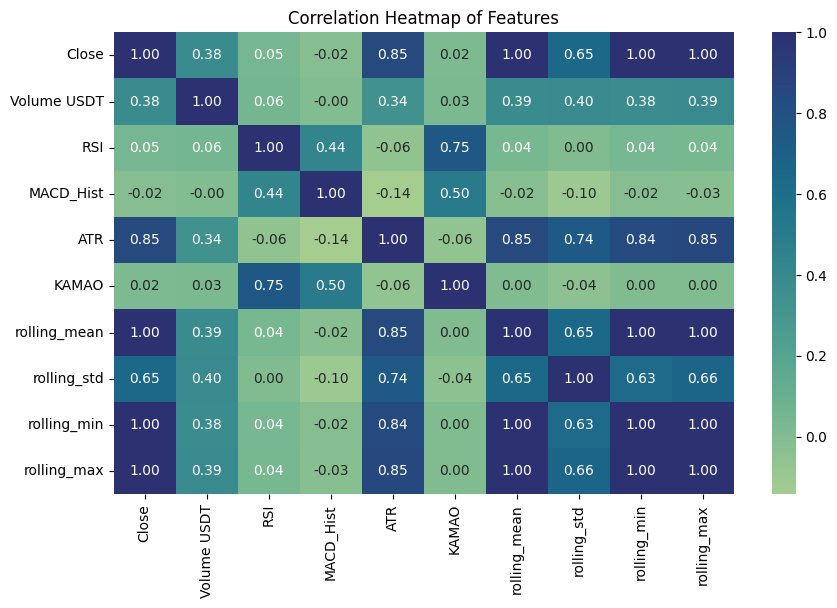

In [20]:
corr = df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='crest')
plt.title('Correlation Heatmap of Features')

# Pipeline & Preprocessing

In [21]:
# Feature Selection
feature_to_use = ['Close', 'Volume USDT', 'RSI', 'rolling_std', 'MACD_Hist']
df_main = df[feature_to_use]
df_main.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 53127 entries, 2017-09-22 08:00:00 to 2023-10-19 23:00:00
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close        53127 non-null  float64
 1   Volume USDT  53127 non-null  float64
 2   RSI          53127 non-null  float64
 3   rolling_std  53127 non-null  float64
 4   MACD_Hist    53127 non-null  float64
dtypes: float64(5)
memory usage: 2.4 MB


In [22]:
# Data Splitting
n = len(df_main)

train_split = int(n * 0.8)
val_split = int(n * 0.9)

train_data = df_main.iloc[:train_split]
val_data = df_main.iloc[train_split:val_split]
test_data = df_main.iloc[val_split:]

print("Train Shape:", train_data.shape)
print("Val Shape:", val_data.shape)
print("Test Shape:", test_data.shape)

Train Shape: (42501, 5)
Val Shape: (5313, 5)
Test Shape: (5313, 5)


In [23]:
# Scaling using MinMax Scaler
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

In [24]:
WINDOW_SIZE = 48
HORIZON = 24
BATCH_SIZE = 32

def make_baseline_window(window, horizon):
  X = window[:-horizon]
  y = window[-horizon:, 0:1]
  return X, y


def create_baseline_dataset(series, window_size, horizon, batch_size):
  ds = tf.data.Dataset.from_tensor_slices(series)
  ds = ds.window(window_size + horizon, shift=1, drop_remainder=True)
  ds = ds.flat_map(lambda w: w.batch(window_size + horizon))
  ds = ds.map(lambda w: make_baseline_window(w, horizon))
  return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def make_multivariate_windows(window, horizon):
    encoder_input = window[:-horizon]
    decoder_target = window[-horizon:, 0:1]

    start_token = encoder_input[-1:, 0:1]
    decoder_input = tf.concat([start_token, decoder_target[:-1]], axis=0)

    return (encoder_input, decoder_input), decoder_target


def create_multivariate_dataset(series, window_size, horizon, batch_size):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + horizon, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size + horizon))
    ds = ds.map(lambda w: make_multivariate_windows(w, horizon))
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds_baseline = create_baseline_dataset(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
val_ds_baseline = create_baseline_dataset(val_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
test_ds_baseline = create_baseline_dataset(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)

train_ds_multi = create_multivariate_dataset(train_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
val_ds_multi = create_multivariate_dataset(val_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)
test_ds_multi = create_multivariate_dataset(test_scaled, WINDOW_SIZE, HORIZON, BATCH_SIZE)

I0000 00:00:1777005872.902698      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Modeling

In [25]:
class CustomDense(tf.keras.layers.Layer):
  def __init__(self, units, **kwargs):
    super(CustomDense, self).__init__(**kwargs)
    self.units = units

  def build(self, input_shape):
    self.w = self.add_weight(
        shape=(input_shape[-1], self.units),
        initializer='random_normal',
        trainable=True,
        name='weight_w'
    )

    self.b = self.add_weight(
        shape=(self.units,),
        initializer='zeros',
        trainable=True,
        name='bias_b'
    )

  def call(self, inputs):
    return tf.matmul(inputs, self.w) + self.b

  def compute_output_shape(self, input_shape):
    return input_shape[:-1] + (self.units,)

class CustomDropout(tf.keras.layers.Layer):
  def __init__(self, rate, **kwargs):
    super(CustomDropout, self).__init__(**kwargs)
    self.rate = rate

  def call(self, inputs, training=None):
    if training:
      return tf.nn.dropout(inputs, rate=self.rate)

    return inputs

class CustomCallback(tf.keras.callbacks.Callback):
  def __init__(self, patience=5):
    super().__init__()
    self.patience = patience
    self.best_weights = None
    self.best_train_loss = float('inf')
    self.best_val_loss = float('inf')
    self.best_epoch = 0
    self.wait = 0

  def on_epoch_end(self, epoch, logs=None):
    current_val_loss = logs.get('val_loss')
    current_train_loss = logs.get('loss')

    if current_val_loss < self.best_val_loss:
      self.best_val_loss = current_val_loss
      self.best_train_loss = current_train_loss
      self.best_epoch = epoch + 1
      self.wait = 0
      self.best_weights = self.model.get_weights()

      print(f"\n--- New Loss {self.best_val_loss:.4f} (Epoch {self.best_epoch})")
    else:
      self.wait += 1
      if self.wait >= self.patience:
        self.model.stop_training = True
        self.model.set_weights(self.best_weights)
        print(f"\nEpoch {epoch+1}: Early Stopping active!")
        print(f"    > Best Train Loss: {self.best_train_loss:.4f}")
        print(f"    > Best Val Loss  : {self.best_val_loss:.4f}")

class CustomLeakyReLU(tf.keras.layers.Layer):
  def __init__(self, alpha=0.3, **kwargs):
    super(CustomLeakyReLU, self).__init__(**kwargs)
    self.alpha = alpha

  def call(self, inputs):
    return tf.maximum(inputs, self.alpha * inputs)

class CustomLayerNormalization(tf.keras.layers.Layer):
    def __init__(self, epsilon=1e-6, **kwargs):
        super(CustomLayerNormalization, self).__init__(**kwargs)
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name='gamma',
            shape=(input_shape[-1],),
            initializer='ones',
            trainable=True
        )
        
        self.beta = self.add_weight(
            name='beta',
            shape=(input_shape[-1],),
            initializer='zeros',
            trainable=True
        )

    def call(self, inputs):
        mean, variance = tf.nn.moments(inputs, axes=[-1], keepdims=True)
        normalized = (inputs - mean) / tf.math.sqrt(variance + self.epsilon)
        return self.gamma * normalized + self.beta


class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.d_model = num_heads * key_dim

        self.wq = tf.keras.layers.Dense(self.d_model)
        self.wk = tf.keras.layers.Dense(self.d_model)
        self.wv = tf.keras.layers.Dense(self.d_model)

        self.dense = tf.keras.layers.Dense(self.d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q):
        batch_size = tf.shape(q)[0]

        q = self.wq(q)
        k = self.wk(k)
        v = self.wv(v)

        q = self.split_heads(q, batch_size)
        k = self.split_heads(k, batch_size)
        v = self.split_heads(v, batch_size)

        matmul_qk = tf.matmul(q, k, transpose_b=True)

        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)

        scaled_attention = tf.matmul(attention_weights, v)

        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))

        output = self.dense(concat_attention)

        return output

In [26]:
# Baseline LSTM
inputs = tf.keras.layers.Input(shape=(WINDOW_SIZE, train_scaled.shape[1]))
lstm_out = tf.keras.layers.LSTM(128, return_sequences=True)(inputs)
attention_out = CustomMultiHeadAttention(num_heads=4, key_dim=16)(lstm_out, lstm_out, lstm_out)
attention_out = tf.keras.layers.Reshape((WINDOW_SIZE, 64))(attention_out)  
flatten_out = tf.keras.layers.Flatten()(attention_out)
norm_out = CustomLayerNormalization()(flatten_out)
dropout_out = CustomDropout(rate=0.2)(norm_out)
dense_out = CustomDense(HORIZON)(dropout_out)
outputs = tf.keras.layers.Reshape((HORIZON, 1))(dense_out)

model_base = tf.keras.models.Model(inputs=inputs, outputs=outputs)
model_base.compile(optimizer='adam', loss='mae')
early_stopping = CustomCallback(patience=5)
history_base = model_base.fit(
    train_ds_baseline,
    validation_data=val_ds_baseline,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)
model_base.save('model_baseline_LSTM.keras')
print("Model Baseline saved!")

Epoch 1/50


I0000 00:00:1777005877.893312      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1326/Unknown 17s 9ms/step - loss: 0.5636

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



--- New Loss 0.0874 (Epoch 1)
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.5634 - val_loss: 0.0874
Epoch 2/50
1324/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0476
--- New Loss 0.0670 (Epoch 2)
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0476 - val_loss: 0.0670
Epoch 3/50
1323/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0305
--- New Loss 0.0596 (Epoch 3)
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0305 - val_loss: 0.0596
Epoch 4/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0284 - val_loss: 0.0679
Epoch 5/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0268 - val_loss: 0.0624
Epoch 6/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0271 - val_loss: 0.0654
Epoch 7/50
1322/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0345
--- New Loss 0.0596 (Epoch 7)
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0345 - val_loss: 0.0596
Epoch 8/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0747 - val_loss: 0.0

In [27]:
base_loss = model_base.evaluate(test_ds_baseline)
base_pred = model_base.predict(test_ds_baseline)

print("="*50)
print("Baseline LSTM")
print("="*50)
print(f"Best Epoch      : Epoch {early_stopping.best_epoch}")
print(f"Best Train Loss : {early_stopping.best_train_loss:.4f}")
print(f"Best Val Loss   : {early_stopping.best_val_loss:.4f}")
print(f"Test Loss       : {base_loss:.4f}")
print(f"Output Dim      : {base_pred.shape}")
print("="*50)

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1079
164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Baseline LSTM
Best Epoch      : Epoch 15
Best Train Loss : 0.0273
Best Val Loss   : 0.0352
Test Loss       : 0.1077
Output Dim      : (5242, 24, 1)


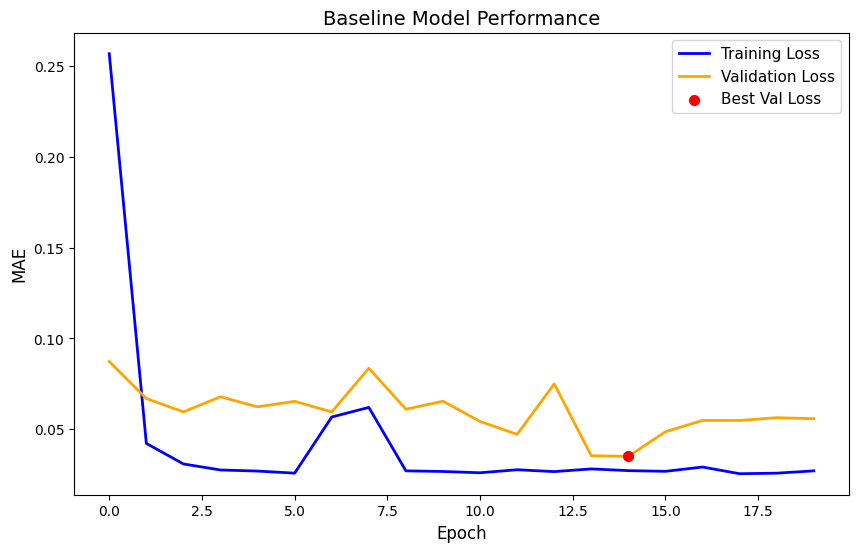

In [28]:
plt.figure(figsize=(10, 6))
train_loss = history_base.history['loss']
val_loss = history_base.history['val_loss']
plt.plot(train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_loss, label='Validation Loss', color='orange', linewidth=2)

best_epoch_index = early_stopping.best_epoch - 1
plt.scatter(best_epoch_index, early_stopping.best_val_loss,
            color='red', s=50, zorder=5,
            label=f'Best Val Loss ')

plt.title('Baseline Model Performance', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.show()

## Seq2Seq

In [29]:
NUM_FEATURES = 5

# Encoder
encoder_inputs = tf.keras.layers.Input(shape=(WINDOW_SIZE, NUM_FEATURES), name="encoder_input")
encoder_lstm = tf.keras.layers.LSTM(128, return_sequences=True, return_state=True, name="encoder_lstm")
encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = tf.keras.layers.Input(shape=(HORIZON, 1), name="decoder_input")
decoder_lstm = tf.keras.layers.LSTM(128, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dropout = CustomDropout(rate=0.2)(decoder_outputs)
decoder_norm = CustomLayerNormalization()(decoder_dropout) 

# Multi Head Attention
attention_layer = CustomMultiHeadAttention(num_heads=4, key_dim=16)
context_vector = attention_layer(v=encoder_outputs, k=encoder_outputs, q=decoder_norm)

# Concat decoder features + context
concat_layer = tf.keras.layers.Concatenate(axis=-1)([decoder_norm, context_vector])

output_layer = tf.keras.layers.TimeDistributed(CustomDense(1), name="output_layer")
outputs = output_layer(concat_layer)

model_functional = tf.keras.Model(
    inputs=[encoder_inputs, decoder_inputs],
    outputs=outputs,
    name="Seq2Seq_Functional_Custom"
)
model_functional.summary()

Model: "Seq2Seq_Functional_Custom"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 48, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 24, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 48, 128), │     68,608 │ encoder_input[0]… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 24, 128), │     66,560 │ decoder_input[0]… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_dropout_1    │ (None, 24, 128)   │          0 │ decoder_lstm[0][… │
│ (CustomDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_layer_norma… │ (None, 24, 128)   │        256 │ custom_dropout_1… │
│ (CustomLayerNormal… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ custom_multi_head_… │ (None, None, 64)  │     28,928 │ encoder_lstm[0][… │
│ (CustomMultiHeadAt… │                   │            │ custom_layer_nor… │
│                     │                   │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 192)   │          0 │ custom_layer_nor… │
│ (Concatenate)       │                   │            │ custom_multi_hea… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer        │ (None, 24, 1)     │        193 │ concatenate[0][0] │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 164,545 (642.75 KB)

 Trainable params: 164,545 (642.75 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model_functional.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae'
)

functional_callback = CustomCallback(patience=5)

history_functional = model_functional.fit(
    train_ds_multi, 
    validation_data=val_ds_multi,
    epochs=50,
    callbacks=[functional_callback],
    verbose=1
)

Epoch 1/50
   1324/Unknown 30s 20ms/step - loss: 0.0769
--- New Loss 0.0827 (Epoch 1)
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - loss: 0.0768 - val_loss: 0.0827
Epoch 2/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - loss: 0.0275 - val_loss: 0.0904
Epoch 3/50
1324/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0323
--- New Loss 0.0796 (Epoch 3)
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - loss: 0.0322 - val_loss: 0.0796
Epoch 4/50
1325/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0291
--- New Loss 0.0697 (Epoch 4)
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - loss: 0.0291 - val_loss: 0.0697
Epoch 5/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - loss: 0.0272 - val_loss: 0.0775
Epoch 6/50
1324/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0340
--- New Loss 0.0648 (Epoch 6)
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - loss: 0.0340 - val_loss: 0.0648
Epoch 7/50
1326/1326 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0341
--- New Loss 0.0596 (Epoch 7)
1326/1326 ━━━━━━━━

In [31]:
model_functional.save('model_seq2seq_functional.keras')

In [32]:
functional_loss = model_functional.evaluate(test_ds_multi, verbose=0)

for x_batch, y_batch in test_ds_multi.take(1):
    functional_pred = model_functional.predict(x_batch, verbose=0)
    break

print("="*50)
print("🚀 PERFORMANCE REPORT: FUNCTIONAL MODEL")
print("="*50)
print(f"Best Epoch      : Epoch {functional_callback.best_epoch}")
print(f"Best Train Loss : {functional_callback.best_train_loss:.4f}")
print(f"Best Val Loss   : {functional_callback.best_val_loss:.4f}")
print(f"Test Loss (MAE) : {functional_loss:.4f}")
print(f"Output Dim      : {functional_pred.shape}")
print("="*50)

🚀 PERFORMANCE REPORT: FUNCTIONAL MODEL
Best Epoch      : Epoch 20
Best Train Loss : 0.0175
Best Val Loss   : 0.0298
Test Loss (MAE) : 0.0967
Output Dim      : (32, 24, 1)


## Model Subclassing

In [33]:
class Encoder(tf.keras.Model):
    def __init__(self, lstm_units, **kwargs):
        super(Encoder, self).__init__(**kwargs)
        self.lstm_units = lstm_units
        self.lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True)

    def call(self, inputs):
        outputs, state_h, state_c = self.lstm(inputs)
        return outputs, state_h, state_c


class Decoder(tf.keras.Model):
    def __init__(self, lstm_units, **kwargs):
        super().__init__(**kwargs)
        self.lstm = tf.keras.layers.LSTM(lstm_units, return_sequences=True, return_state=True)
        self.dropout1 = CustomDropout(rate=0.2)
        self.norm = CustomLayerNormalization()
        # HAPUS self.dense di sini

    def call(self, inputs, encoder_states, training=None):
        decoder_outputs, state_h, state_c = self.lstm(inputs, initial_state=encoder_states)
        decoder_dropout = self.dropout1(decoder_outputs, training=training)
        norm_out = self.norm(decoder_dropout)
        # HAPUS output = self.dense(norm_out)
        return norm_out, state_h, state_c  # ← return raw features, bukan prediksi


class Seq2SeqModel(tf.keras.Model):
    def __init__(self, lstm_units, **kwargs):
        super().__init__(**kwargs)
        self.encoder = Encoder(lstm_units)
        self.decoder = Decoder(lstm_units)
        self.attention = CustomMultiHeadAttention(num_heads=4, key_dim=16)
        self.concat = tf.keras.layers.Concatenate(axis=-1)
        self.dense_final = CustomDense(1)  # ← satu-satunya Dense

    def call(self, inputs, training=None):
        encoder_inputs, decoder_inputs = inputs
        encoder_outputs, state_h, state_c = self.encoder(encoder_inputs)
        encoder_states = [state_h, state_c]

        decoder_features, _, _ = self.decoder(decoder_inputs, encoder_states, training=training)

        context = self.attention(encoder_outputs, encoder_outputs, decoder_features)
        concat_out = self.concat([decoder_features, context])
        output = self.dense_final(concat_out)  # ← baru di-Dense di sini
        return output

In [34]:
# Custom Weighted MAE
@tf.function
def custom_weighted_mae(y_true, y_pred):
  y_true = tf.cast(y_true, tf.float32)
  horizon = tf.shape(y_true)[1]
  weights = tf.range(1, horizon + 1, dtype=tf.float32)
  weights = weights / tf.reduce_mean(weights)
  weights = tf.reshape(weights, (1, -1, 1))
  absolute_error = tf.abs(y_true - y_pred)
  weighted_error = absolute_error * weights
  
  return tf.reduce_mean(weighted_error)


class AdvancedCustomCallback(tf.keras.callbacks.Callback):
    def __init__(self, patience=5, reduce_factor=0.5, min_lr=1e-6):
        super().__init__()
        self.patience = patience
        self.reduce_factor = reduce_factor
        self.min_lr = min_lr
        self.wait = 0
        self.best_val_loss = float('inf')
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current_val_loss = logs.get('val_loss')
        
        if current_val_loss < self.best_val_loss:
            self.best_val_loss = current_val_loss
            self.wait = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            
            #Reduce LR on Plateau
            if self.wait >= 2:
                current_lr = float(self.model.optimizer.learning_rate)
                new_lr = max(current_lr * self.reduce_factor, self.min_lr)
                if current_lr > new_lr:
                    self.model.optimizer.learning_rate = float(new_lr)
                    print(f"\n[Info] Validation stuck. Decrease LR to {new_lr:.6f}")

            #Early Stopping
            if self.wait >= self.patience:
                self.model.stop_training = True
                self.model.set_weights(self.best_weights)
                print(f"\nEarly Stopping at Epoch {epoch+1}!")

In [35]:
model_seq2seq = Seq2SeqModel(lstm_units=128) 
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model_seq2seq.optimizer = optimizer
model_seq2seq.stop_training = False 

custom_callback = AdvancedCustomCallback(patience=7, reduce_factor=0.3, min_lr=1e-7)  # patience lebih sabar
custom_callback.set_model(model_seq2seq)

train_loss_tracker = tf.keras.metrics.Mean(name="train_loss")
val_loss_tracker = tf.keras.metrics.Mean(name="val_loss")

epochs = 100  


@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred = model_seq2seq(x_batch, training=True)
        loss_value = custom_weighted_mae(y_batch, y_pred)
    gradients = tape.gradient(loss_value, model_seq2seq.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model_seq2seq.trainable_variables))
    return loss_value

@tf.function
def val_step(x_batch, y_batch):
    val_pred = model_seq2seq(x_batch, training=False)
    val_loss = custom_weighted_mae(y_batch, val_pred)
    return val_loss

In [36]:
print("="*50)
print("🚀 START CUSTOM TRAINING")
print("="*50)

for epoch in range(epochs):
    start_time = time.time()
    
    # Fase Training
    for x_batch_train, y_batch_train in train_ds_multi:
        loss_value = train_step(x_batch_train, y_batch_train)
        train_loss_tracker.update_state(loss_value)
        
    # Fase Validation
    for x_batch_val, y_batch_val in val_ds_multi:
        val_loss = val_step(x_batch_val, y_batch_val)
        val_loss_tracker.update_state(val_loss)

    # Evaluasi Epoch
    current_train_loss = train_loss_tracker.result().numpy()
    current_val_loss = val_loss_tracker.result().numpy()
    
    time_taken = time.time() - start_time
    print(f"Epoch {epoch + 1}/{epochs} | {int(time_taken)}s - loss: {current_train_loss:.4f} - val_loss: {current_val_loss:.4f}")
    
    # Callback
    logs = {'loss': current_train_loss, 'val_loss': current_val_loss}
    custom_callback.on_epoch_end(epoch, logs)
    
    if model_seq2seq.stop_training:
        print(f"Training stop.")
        break
        
    train_loss_tracker.reset_state()
    val_loss_tracker.reset_state()

print("\n" + "="*50)
print("✅ CUSTOM TRAINING FINISH")
print("="*50)

model_seq2seq.save('model_seq2seq_LSTM.keras')
model_seq2seq.save('best_model_seq2seq_LSTM.keras')
print("Model Custom Training saved!")

🚀 START CUSTOM TRAINING
Epoch 1/100 | 18s - loss: 0.0405 - val_loss: 0.0803
Epoch 2/100 | 14s - loss: 0.0293 - val_loss: 0.0979
Epoch 3/100 | 14s - loss: 0.0306 - val_loss: 0.0794
Epoch 4/100 | 14s - loss: 0.0307 - val_loss: 0.0826
Epoch 5/100 | 14s - loss: 0.0319 - val_loss: 0.0776
Epoch 6/100 | 14s - loss: 0.0332 - val_loss: 0.0643
Epoch 7/100 | 14s - loss: 0.0297 - val_loss: 0.0754
Epoch 8/100 | 14s - loss: 0.0294 - val_loss: 0.0732

[Info] Validation stuck. Decrease LR to 0.000300
Epoch 9/100 | 14s - loss: 0.0328 - val_loss: 0.0348
Epoch 10/100 | 14s - loss: 0.0280 - val_loss: 0.0356
Epoch 11/100 | 14s - loss: 0.0248 - val_loss: 0.0393

[Info] Validation stuck. Decrease LR to 0.000090
Epoch 12/100 | 14s - loss: 0.0575 - val_loss: 0.0337
Epoch 13/100 | 14s - loss: 0.0383 - val_loss: 0.0267
Epoch 14/100 | 14s - loss: 0.0280 - val_loss: 0.0322
Epoch 15/100 | 14s - loss: 0.0227 - val_loss: 0.0379

[Info] Validation stuck. Decrease LR to 0.000027
Epoch 16/100 | 14s - loss: 0.0280 - val_

In [37]:
model_seq2seq.compile(loss='mae')

seq2seq_loss = model_seq2seq.evaluate(test_ds_multi, verbose=0)

print("="*50)
print("EVALUATION (On test Data): Seq2Seq LSTM")
print("="*50)
print(f"Best Val Loss   : {custom_callback.best_val_loss:.4f}")
print(f"Test Loss (MAE) : {seq2seq_loss:.4f}")
print("="*50)

EVALUATION (On test Data): Seq2Seq LSTM
Best Val Loss   : 0.0267
Test Loss (MAE) : 0.0711


# Inference

In [38]:
def autoregressive_predict(model, x_past, horizon=24):
    encoder_outputs, state_h, state_c = model.encoder(x_past)
    states = [state_h, state_c]
    
    dec_input = x_past[:, -1:, 0:1]
    predictions = []
    
    for _ in range(horizon):
        dec_features, state_h, state_c = model.decoder(dec_input, states, training=False)
        
        # Attention + concat + dense 
        context = model.attention(encoder_outputs, encoder_outputs, dec_features)
        concat_out = model.concat([dec_features, context])
        pred = model.dense_final(concat_out)  # shape: (1, 1, 1)
        
        predictions.append(pred)
        dec_input = pred 
        states = [state_h, state_c]
    
    return tf.concat(predictions, axis=1)

# Predict Data & Inverse Scaling
for (x_past_batch, x_teacher_batch), y_true_batch in test_ds_multi.take(1):
    sample_x_past = x_past_batch[0:1] 
    sample_y_true = y_true_batch[0]
    break

pred_seq2seq_scaled = autoregressive_predict(model_seq2seq, sample_x_past, horizon=HORIZON)
pred_baseline_scaled = model_base.predict(sample_x_past)

seq_scaled_flat = pred_seq2seq_scaled.numpy().flatten()
base_scaled_flat = pred_baseline_scaled[0].flatten()
aktual_scaled_flat = sample_y_true.numpy().flatten()

num_features = train_scaled.shape[1] 

# Inverse Actual
dummy_actual = np.zeros((HORIZON, num_features))
dummy_actual[:, 0] = aktual_scaled_flat
actual_og = scaler.inverse_transform(dummy_actual)[:, 0]

# Inverse Prediction Seq2Seq
dummy_seq = np.zeros((HORIZON, num_features))
dummy_seq[:, 0] = seq_scaled_flat
pred_seq_og = scaler.inverse_transform(dummy_seq)[:, 0]

# Inverse Prediksi Baseline
dummy_base = np.zeros((HORIZON, num_features))
dummy_base[:, 0] = base_scaled_flat
pred_base_og = scaler.inverse_transform(dummy_base)[:, 0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


In [39]:
# Visualization
df_result = pd.DataFrame({
    "Steps (hr)": range(1, HORIZON + 1),
    "Actual Price": actual_og,             
    "Seq2Seq Prediction": pred_seq_og,
    "Baseline Prediction": pred_base_og
})

df_result["Absolute Error (Seq2Seq)"] = np.abs(df_result["Actual Price"] - df_result["Seq2Seq Prediction"])

print("\n--- ACTUAL PRICE VS PREDICTION TABLE ---")
display(df_result.head(10))


--- ACTUAL PRICE VS PREDICTION TABLE ---


,Steps (hr),Actual Price,Seq2Seq Prediction,Baseline Prediction,Absolute Error (Seq2Seq)
0,1,25759.64,24202.584562,20546.319863,1557.055438
1,2,25815.75,25597.459063,20621.256224,218.290937
2,3,25894.67,25703.637280,20705.917867,191.032720
3,4,25867.21,25638.646652,20757.720351,228.563348
4,5,25628.25,25503.596934,20855.302863,124.653066
5,6,24990.18,25430.666107,20713.093310,440.486107
6,7,25054.15,25395.840432,20991.006135,341.690432
7,8,24570.06,25377.349717,21120.932766,807.289717
8,9,24535.95,25366.625571,21080.734288,830.675571
9,10,24698.39,25360.002235,21301.594734,661.612235


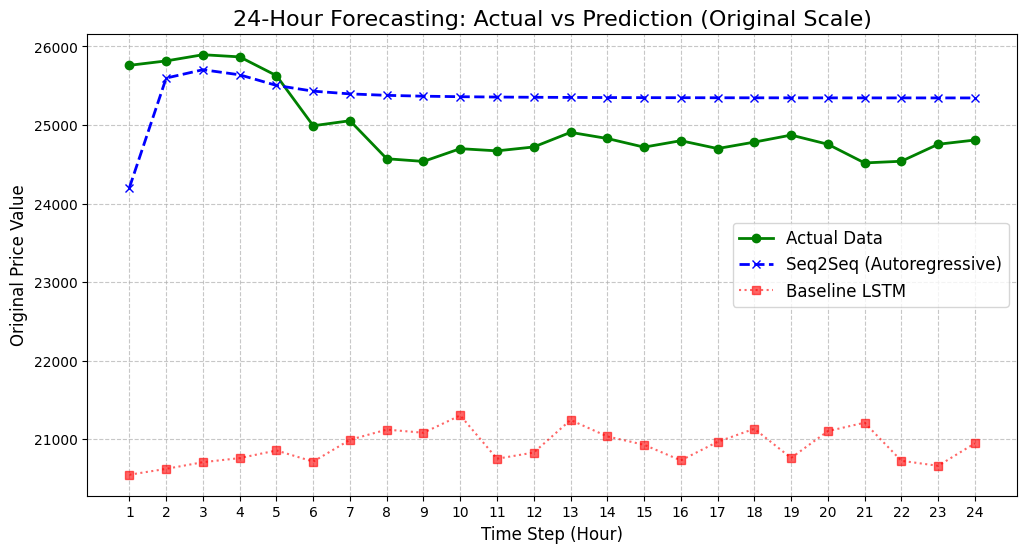

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(df_result["Steps (hr)"], df_result["Actual Price"], label='Actual Data', color='green', marker='o', linewidth=2)
plt.plot(df_result["Steps (hr)"], df_result["Seq2Seq Prediction"], label='Seq2Seq (Autoregressive)', color='blue', marker='x', linestyle='dashed', linewidth=2)
plt.plot(df_result["Steps (hr)"], df_result["Baseline Prediction"], label='Baseline LSTM', color='red', marker='s', linestyle='dotted', alpha=0.6)

plt.title('24-Hour Forecasting: Actual vs Prediction (Original Scale)', fontsize=16)
plt.xlabel('Time Step (Hour)', fontsize=12)
plt.ylabel('Original Price Value', fontsize=12)
plt.xticks(range(1, HORIZON + 1))
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()